<a href="https://colab.research.google.com/github/heisenberg-611/E-Commerce-Website-Delivery-Prediction-Model/blob/main/CSE422_Project_Spring26(E_commarce_Shipping_Delivery_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-commerce Shipping Delivery Prediction

## 1. Introduction
This project aims to predict whether an e-commerce shipment will reach its destination on time based on various factors like the mode of shipment, customer ratings, cost of the product, weight, and more. Predicting on-time delivery can help the company optimize their logistics and improve customer satisfaction.

**Dataset**: E-commerce Shipping Dataset.

**Target Variable**: `Reached.on.Time_Y.N` (1/0)


## 1. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Successfully imported all necessary data science and machine learning libraries for the pipeline.")

Successfully imported all necessary data science and machine learning libraries for the pipeline.


## 2. Dataset Description

In [ ]:
df = pd.read_csv('https://drive.usercontent.google.com/download?id=17B1ZL_Wm58Wts1Wl4aBdBak_NFOy-Aj9&export=download&authuser=0')

if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
display(df.head())

print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns. The ID column was dropped because it is non-predictive noise.")


Dataset Shape: (10999, 11)

Data Types:
 Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

First 5 rows:


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


The dataset has 10999 rows and 11 columns. The ID column was dropped because it is non-predictive noise.


In [ ]:
print("This is a Classification problem because our target variable 'Reached.on.Time_Y.N' is discrete and categorical (binary).")

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
quantitative_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
quantitative_cols.remove('Reached.on.Time_Y.N')

print(f"\nCategorical Features: {categorical_cols}")
print(f"\nQuantitative Features: {quantitative_cols}")

print(f"\nIdentified {len(categorical_cols)} text features needing Label Encoding and {len(quantitative_cols)} numerical features needing Standard Scaling.")

This is a Classification problem because our target variable 'Reached.on.Time_Y.N' is discrete and categorical (binary).

Categorical Features: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

Quantitative Features: ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

Identified 4 text features needing Label Encoding and 6 numerical features needing Standard Scaling.


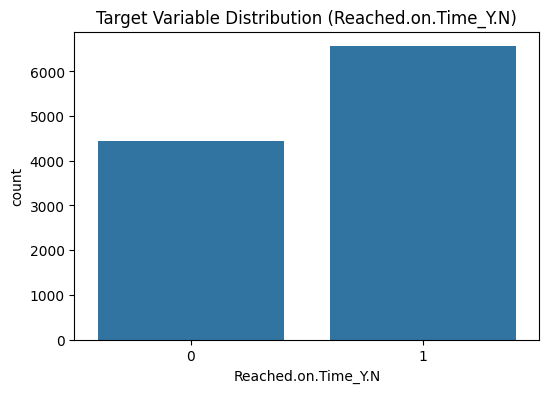

Class Counts:
 Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64
The dataset is relatively balanced.
We don't need any extreme oversampling methods


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Reached.on.Time_Y.N', data=df)
plt.title('Target Variable Distribution (Reached.on.Time_Y.N)')
plt.show()

class_counts = df['Reached.on.Time_Y.N'].value_counts()
print("Class Counts:\n", class_counts)
if abs(class_counts[0] - class_counts[1]) > (0.2 * len(df)):
    print("The dataset is somewhat imbalanced.")
else:
    print("The dataset is relatively balanced.")

print("We don't need any extreme oversampling methods")

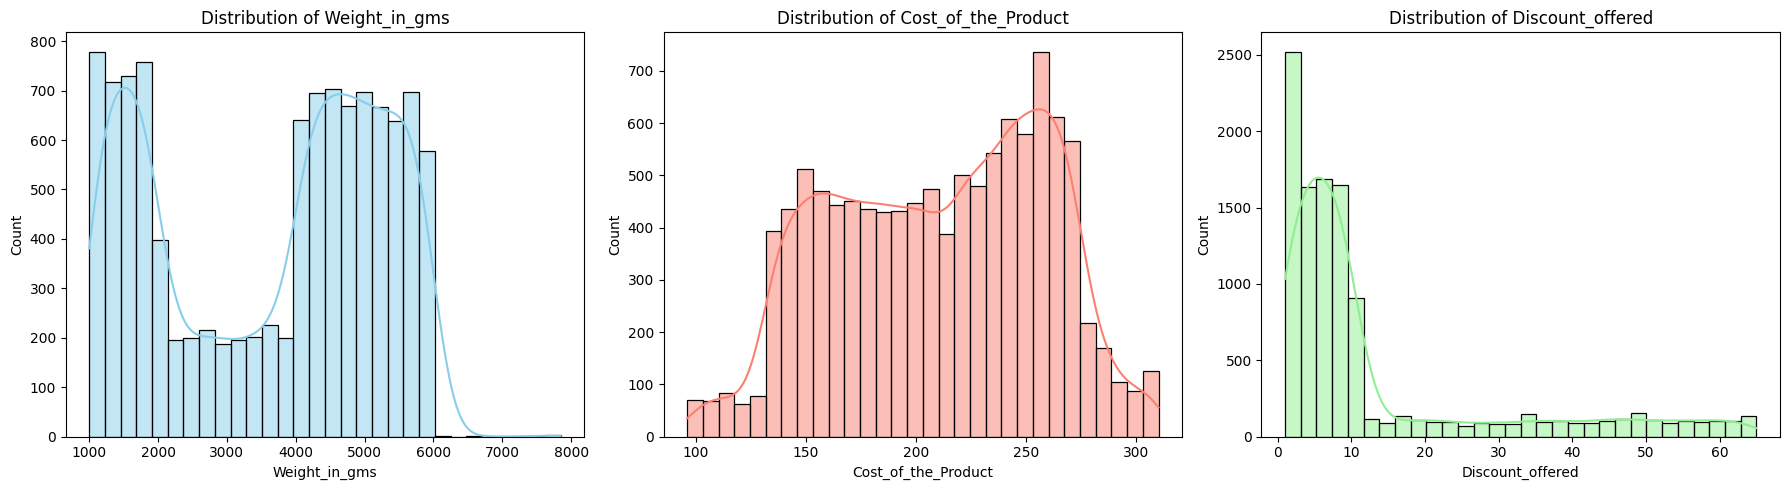


Continuous features have vastly different scales and distribution. We need standerd scalling


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Weight_in_gms'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Weight_in_gms')

sns.histplot(df['Cost_of_the_Product'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Cost_of_the_Product')

sns.histplot(df['Discount_offered'], bins=30, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Discount_offered')

plt.tight_layout()
plt.show()

print("\nContinuous features have vastly different scales and distribution. We need standerd scalling")

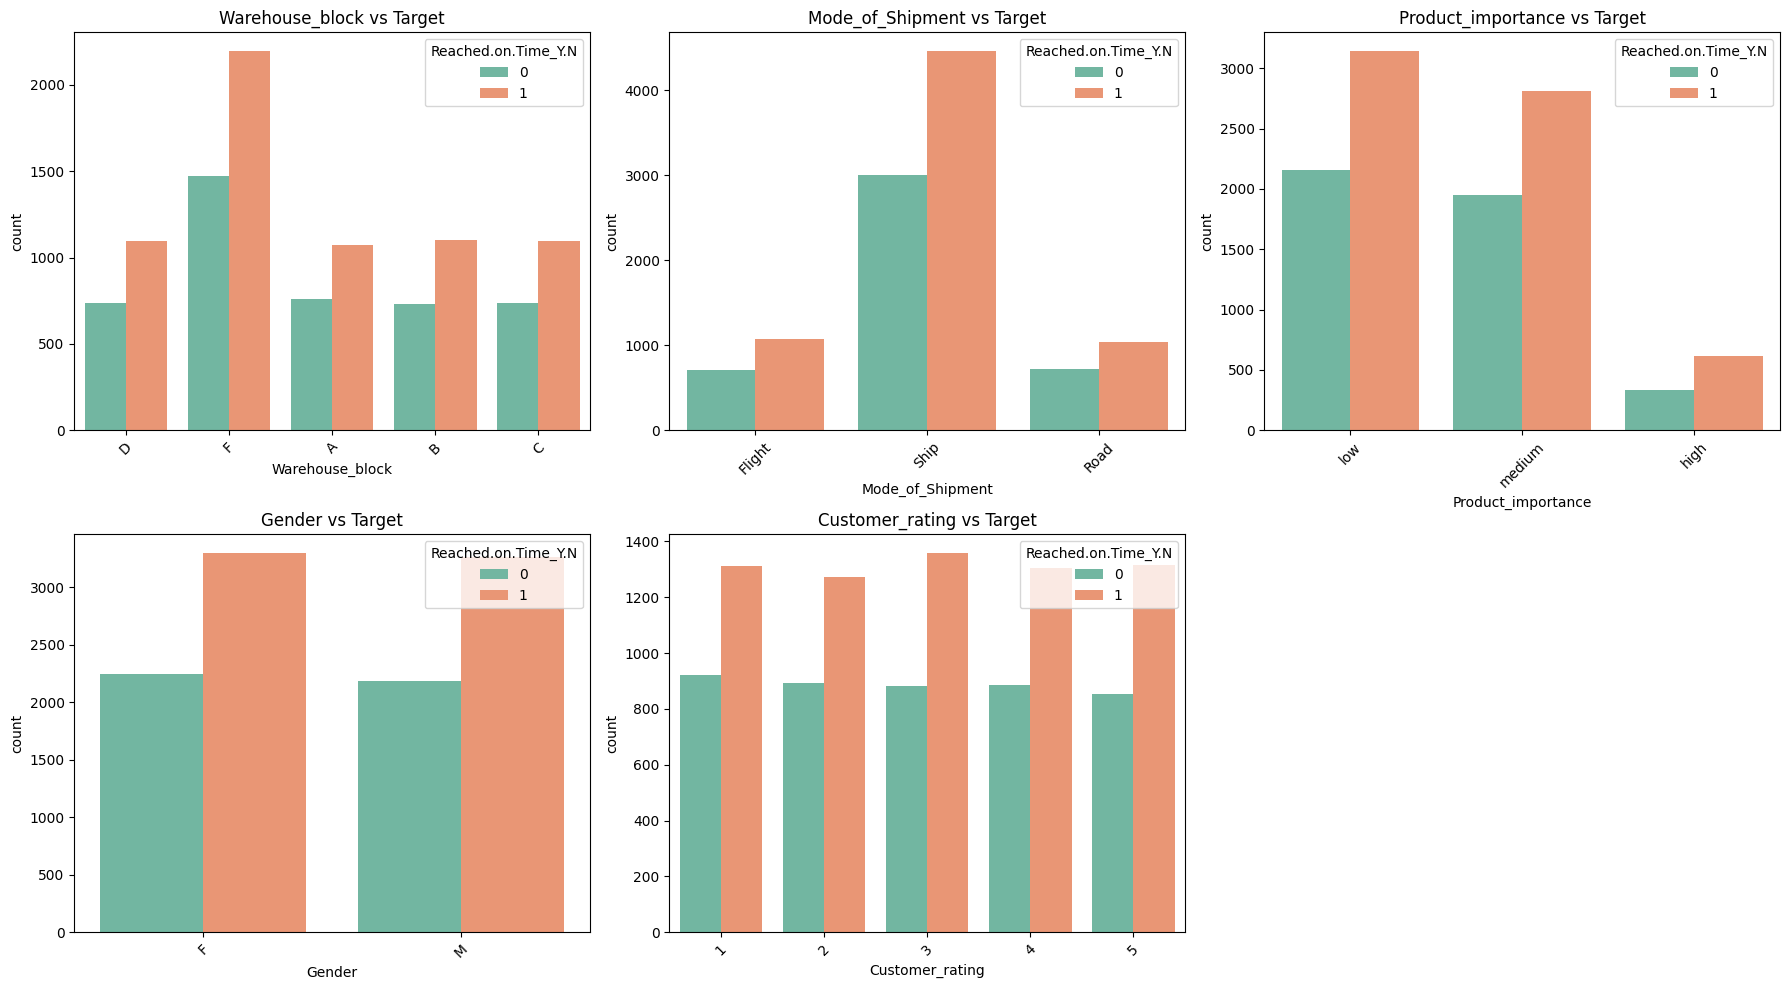


Warehouse block and Mode of shipment show variations in delays, indicating they hold predictive value.


In [ ]:
cat_features = categorical_cols + (['Customer_rating'] if 'Customer_rating' not in categorical_cols else [])
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    if i < len(axes):
        sns.countplot(x=col, hue='Reached.on.Time_Y.N', data=df, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{col} vs Target')
        axes[i].tick_params(axis='x', rotation=45)

if len(cat_features) < len(axes):
    for j in range(len(cat_features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("\nWarehouse block and Mode of shipment show variations in delays, indicating they hold predictive value.")

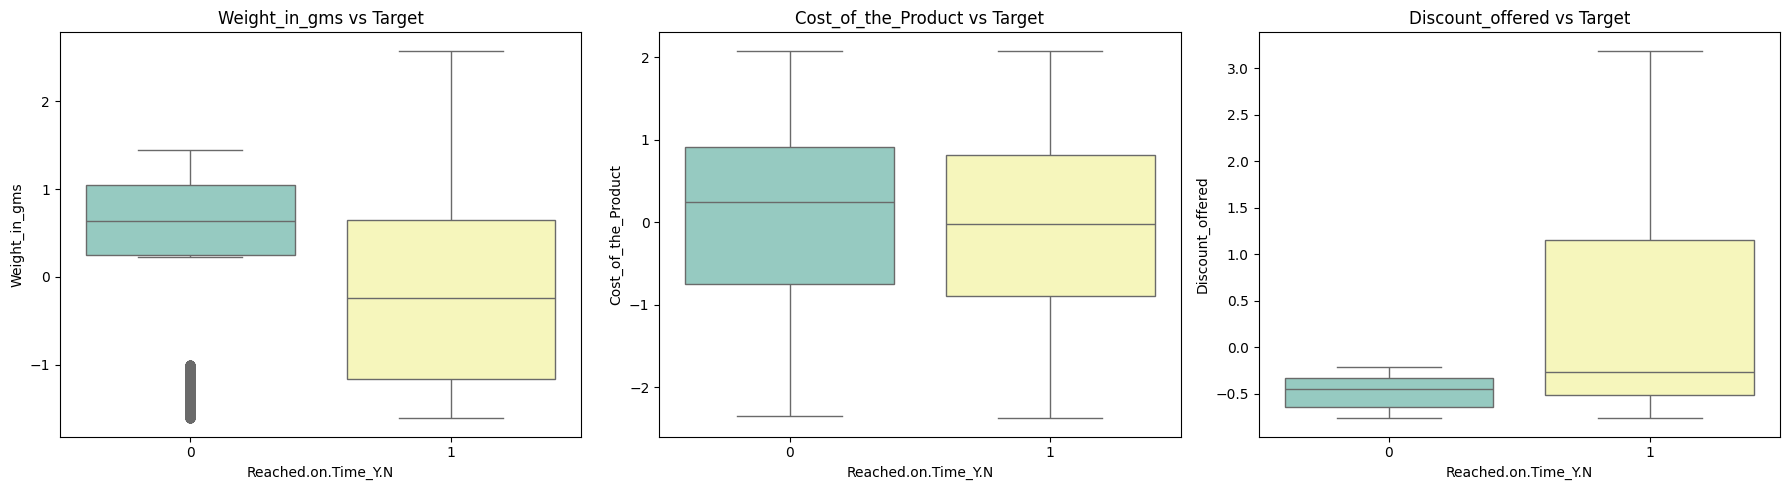


Discount_offered has extreme outliers for late shipments, acting as a massive visual indicator of delayed delivery.


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Reached.on.Time_Y.N', y='Weight_in_gms', data=df, ax=axes[0], palette='Set3')
axes[0].set_title('Weight_in_gms vs Target')

sns.boxplot(x='Reached.on.Time_Y.N', y='Cost_of_the_Product', data=df, ax=axes[1], palette='Set3')
axes[1].set_title('Cost_of_the_Product vs Target')

sns.boxplot(x='Reached.on.Time_Y.N', y='Discount_offered', data=df, ax=axes[2], palette='Set3')
axes[2].set_title('Discount_offered vs Target')

plt.tight_layout()
plt.show()

print("\nDiscount_offered has extreme outliers for late shipments, acting as a massive visual indicator of delayed delivery.")


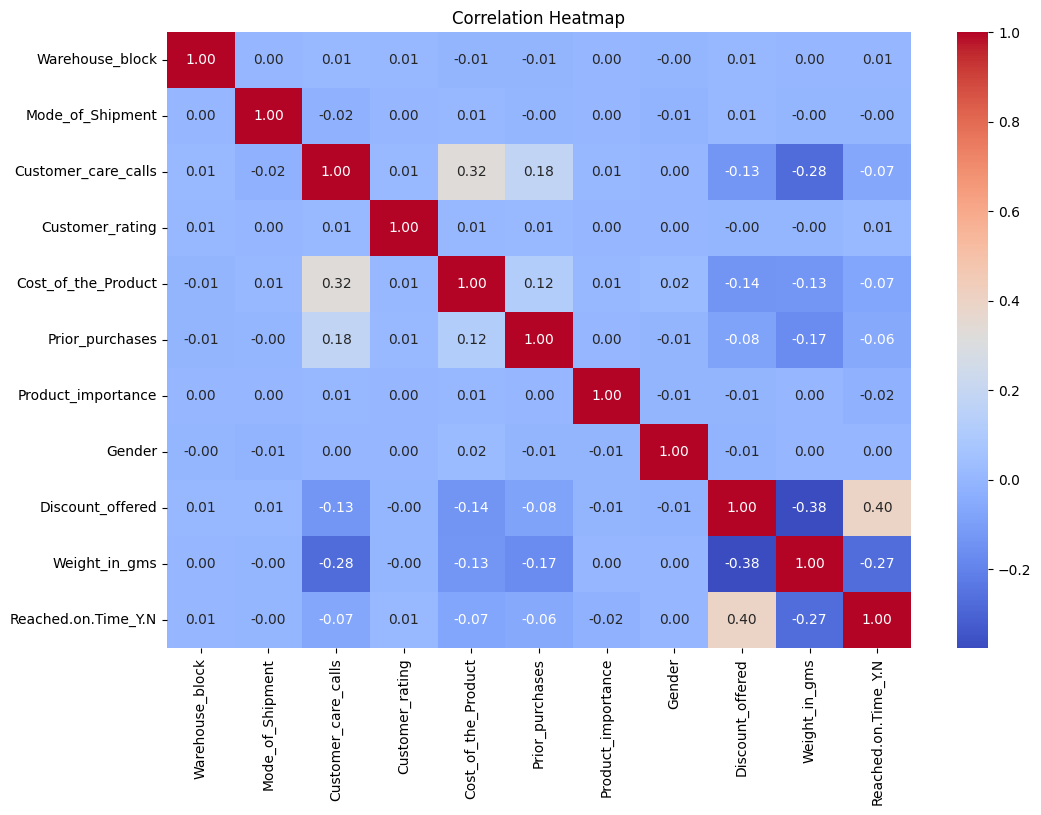


From the correlation heatmap, we can observe the linear relationship between different features and the target variable. For example, Discount_offered seems to have a higher positive correlation with the target variable compared to other features.

Mathematically confirmed that 'Discount_offered' has the highest positive correlation with late deliveries.


In [27]:
df_encoded_temp = df.copy()
le = LabelEncoder()
for col in categorical_cols:
    df_encoded_temp[col] = le.fit_transform(df_encoded_temp[col])

plt.figure(figsize=(12, 8))
corr_matrix = df_encoded_temp.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

print("\nFrom the correlation heatmap, we can observe the linear relationship between different features and the target variable. For example, Discount_offered seems to have a higher positive correlation with the target variable compared to other features.")

print("\nMathematically confirmed that 'Discount_offered' has the highest positive correlation with late deliveries.")

## 3. Dataset pre-processing


In [28]:
print("Null Values Check:")
print(df.isnull().sum())
print("\nNo missing values found in the dataset.")

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
print("\nCategorical features encoded using LabelEncoder.")

scaler = StandardScaler()
df[quantitative_cols] = scaler.fit_transform(df[quantitative_cols])
print("Quantitative features scaled using StandardScaler.")

display(df.head())

Null Values Check:
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

No missing values found in the dataset.

Categorical features encoded using LabelEncoder.
Quantitative features scaled using StandardScaler.


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,3,0,-0.047711,-0.700755,-0.690722,-0.372735,1,0,1.889983,-1.468240,1
1,4,0,-0.047711,1.421578,0.120746,-1.029424,1,1,2.815636,-0.333893,1
2,0,0,-1.799887,-0.700755,-0.565881,0.283954,1,1,2.136824,-0.159002,1
3,1,0,-0.923799,0.006689,-0.711529,0.283954,2,1,-0.208162,-1.502484,1
4,2,0,-1.799887,-0.700755,-0.545074,-0.372735,2,0,2.013404,-0.703244,1


## 4. Dataset splitting

In [33]:
X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nDivided the dataset into 80% training pool and 20% testing pool")

Training set shape: (8799, 10)
Testing set shape: (2200, 10)

Divided the dataset into 80% training pool and 20% testing pool


## 5. Model training (Supervised)
Used three models: Logistic Regression, Decision Tree, and Neural Network (MLP) for training.


In [34]:
# 1. Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# 2. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# 3. Neural Network (MLP Classifier)
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)
y_prob_nn = nn_model.predict_proba(X_test)[:, 1]

models = ['Logistic Regression', 'Decision Tree', 'Neural Network']
predictions = [y_pred_lr, y_pred_dt, y_pred_nn]
probabilities = [y_prob_lr, y_prob_dt, y_prob_nn]

print("Successfully trained 3 diverse algorithms (Linear, Tree, Neural) on the 80% training data.")


Successfully trained 3 diverse algorithms (Linear, Tree, Neural) on the 80% training data.


## 6. Unsupervised Learning

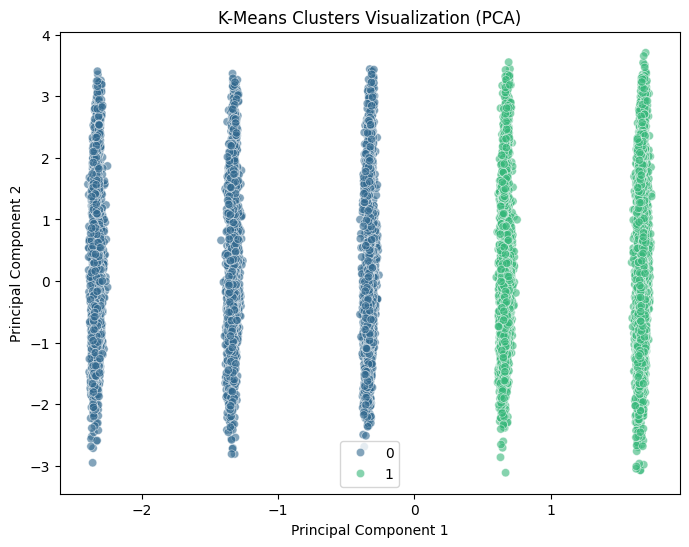

In [36]:
X_unsupervised = df.drop('Reached.on.Time_Y.N', axis=1)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_unsupervised)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_unsupervised)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', alpha=0.6)
plt.title('K-Means Clusters Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## 7. Model selection/Comparison analysis
Evaluating and comparing the models using Accuracy, Precision, Recall, Confusion Matrix, and ROC AUC.


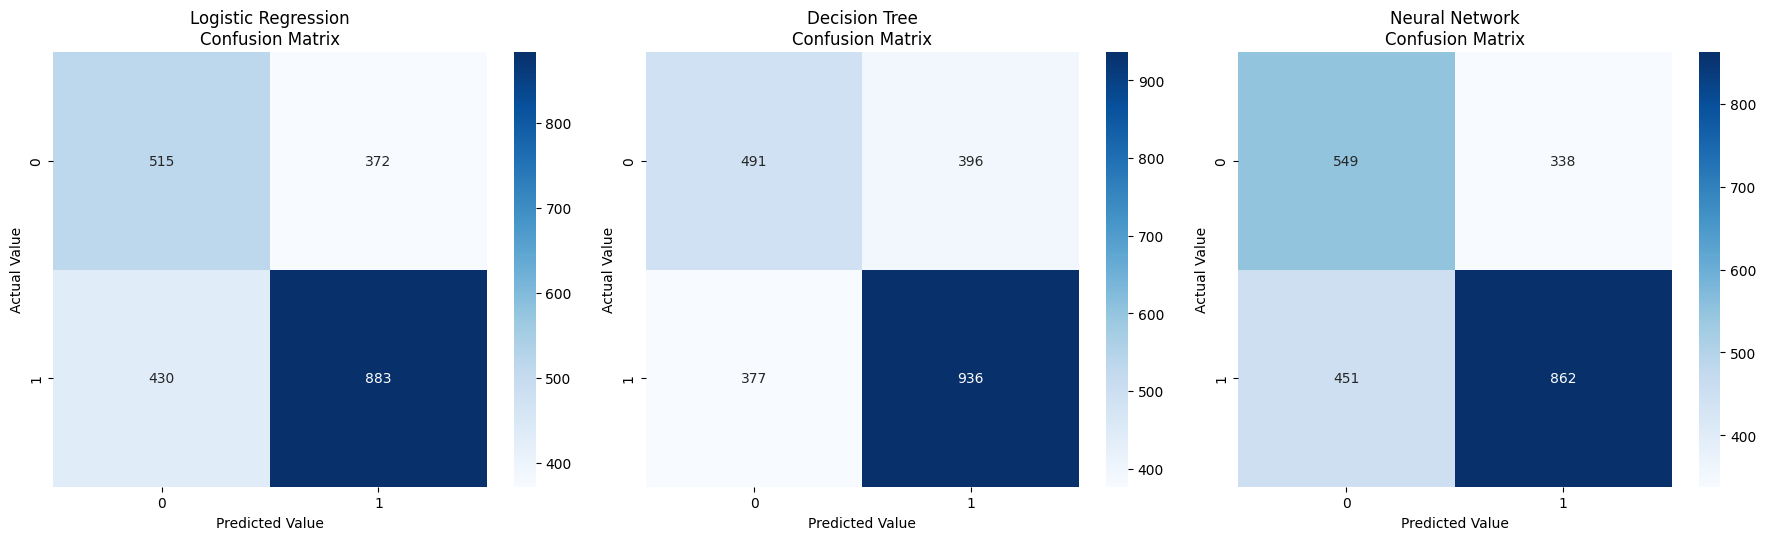

In [42]:
accuracies = []
precisions = []
recalls = []

plt.figure(figsize=(18, 10))

for i, model_name in enumerate(models):
    acc = accuracy_score(y_test, predictions[i])
    prec = precision_score(y_test, predictions[i])
    rec = recall_score(y_test, predictions[i])

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

    cm = confusion_matrix(y_test, predictions[i])
    plt.subplot(2, 3, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name}\nConfusion Matrix')
    plt.xlabel('Predicted Value')
    plt.ylabel('Actual Value')

plt.tight_layout()
plt.show()


## 8. Classification Reports

In [43]:
for i, model_name in enumerate(models):
    print(f"--- {model_name} Classification Report ---")
    print(classification_report(y_test, predictions[i]))
    print("\n")

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.54      0.58      0.56       887
           1       0.70      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.62      0.63      0.62      2200
weighted avg       0.64      0.64      0.64      2200



--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.57      0.55      0.56       887
           1       0.70      0.71      0.71      1313

    accuracy                           0.65      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.65      0.65      2200



--- Neural Network Classification Report ---
              precision    recall  f1-score   support

           0       0.55      0.62      0.58       887
           1       0.72      0.66      0.69      1313

    accuracy                           

Model Accuracy Comparison

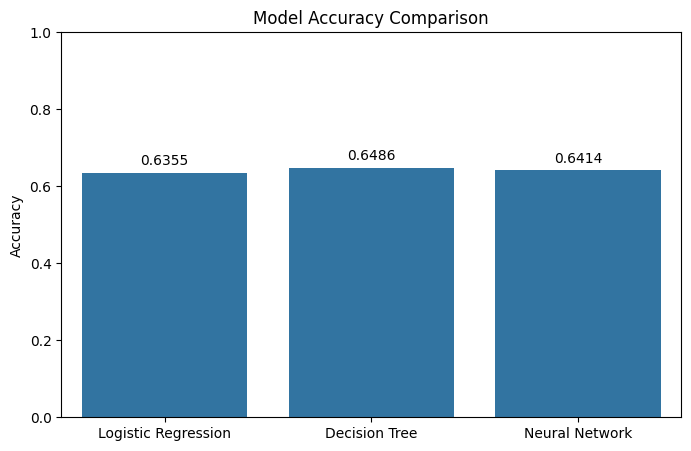

In [44]:
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, str(round(v, 4)), ha='center')
plt.show()

Precision and Recall

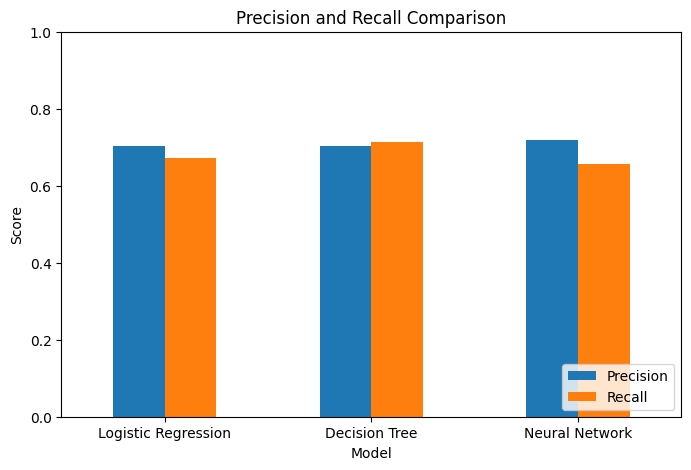

In [45]:
metrics_df = pd.DataFrame({
    'Model': models,
    'Precision': precisions,
    'Recall': recalls
})

metrics_df.set_index('Model').plot(kind='bar', figsize=(8, 5))
plt.title('Precision and Recall Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

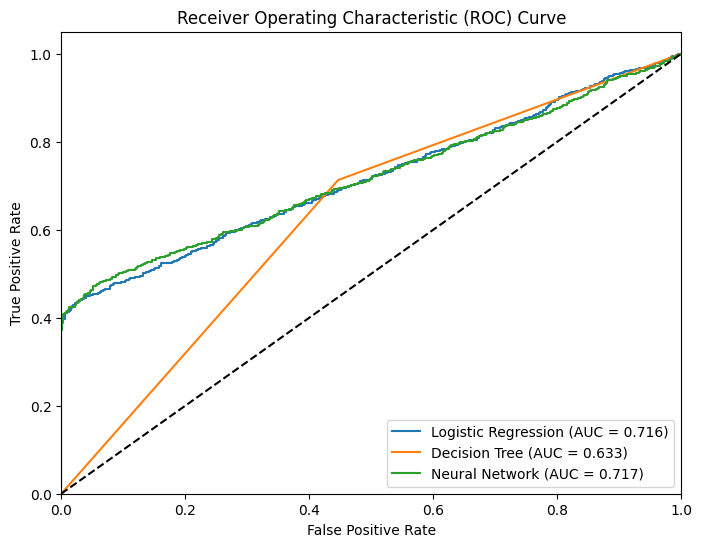

In [46]:
plt.figure(figsize=(8, 6))

for i, model_name in enumerate(models):
    fpr, tpr, _ = roc_curve(y_test, probabilities[i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()